In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Qiskit primitives
from qiskit.primitives import StatevectorEstimator

# Algorithms
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA

# Ansatz
from qiskit.circuit.library import n_local

# Qiskit Nature
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.formats.molecule_info import MoleculeInfo
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.circuit.library import HartreeFock
from qiskit_algorithms.optimizers import SLSQP

# --- Setup ---
mapper = JordanWignerMapper()
estimator = StatevectorEstimator()

optimizer = SLSQP(maxiter=1000)
# optimizer = COBYLA(maxiter=100)

distances_N2 = np.linspace(0.4, 1.5, 30)
energies_N2= []

initial_point = None

for d in distances_N2:
    # --- Molecule ---
    mol = MoleculeInfo(
        symbols=["N", "N"],
        coords=[(0.0, 0.0, -d/2), (0.0, 0.0, d/2)],
        multiplicity=1,
        charge=0,
    )

    # --- Driver ---
    driver = PySCFDriver.from_molecule(molecule=mol, basis="sto3g")
    prob = driver.run()

    # --- Freeze core ---
    prob = FreezeCoreTransformer(freeze_core=True).transform(prob)

    # --- Active space ---
    prob = ActiveSpaceTransformer(
        num_electrons=6,
        num_spatial_orbitals=6
    ).transform(prob)

    # --- Hamiltonian ---
    ham = prob.hamiltonian.second_q_op()
    qubit_op = mapper.map(ham)

    # --- Hartree-Fock initial state ---
    hf = HartreeFock(
        num_spatial_orbitals=prob.num_spatial_orbitals,
        num_particles=prob.num_particles,
        qubit_mapper=mapper,
    )

    # --- Hardware-efficient ansatz ---
    he_ansatz = n_local(
        num_qubits=qubit_op.num_qubits,
        rotation_blocks=["ry", "rz"],
        entanglement_blocks="cx",
        entanglement="full",
        reps=5   # optimal range
    )

    # --- Combine HF + ansatz ---
    ansatz = hf.compose(he_ansatz)

    # --- VQE ---
    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer
    )

    # Warm start
    if initial_point is not None:
        vqe.initial_point = initial_point

    result = vqe.compute_minimum_eigenvalue(qubit_op)
    initial_point = result.optimal_point

    # --- Energy ---
    total_energy = prob.interpret(result).total_energies[0]
    energies_N2.append(total_energy)


In [2]:

# # --- Plot ---
# plt.plot(distances_N2, energies_N2, 'o-')
# plt.xlabel("Internuclear distance (Å)")
# plt.ylabel("Ground state energy (Ha)")
# plt.grid()
# plt.show()

# # --- Equilibrium ---
# min_energy = min(energies_N2)
# min_index = energies_N2.index(min_energy)
# equilibrium_distance = distances_N2[min_index]

# print(f"Minimum ground state energy: {min_energy:.8f} Ha")
# print(f"Equilibrium bond distance: {equilibrium_distance:.4f} Å")

In [3]:
print(energies_N2)
print(distances_N2)

[np.float64(-94.4570674266007), np.float64(-97.24202085182324), np.float64(-99.42804652912993), np.float64(-101.156854811458), np.float64(-102.53029266132023), np.float64(-103.62421423335906), np.float64(-104.49637686076001), np.float64(-105.19137707185286), np.float64(-105.7440667469927), np.float64(-106.1819720648605), np.float64(-106.52700283105867), np.float64(-106.79676180983154), np.float64(-107.0054536371343), np.float64(-107.16462112225045), np.float64(-107.28366311993919), np.float64(-107.38275085627966), np.float64(-107.44427948808288), np.float64(-107.489741711125), np.float64(-107.51185191688717), np.float64(-107.52162986706338), np.float64(-107.52897388855916), np.float64(-107.54121528579893), np.float64(-107.57063833109501), np.float64(-107.51706129597271), np.float64(-107.50165622817892), np.float64(-107.48052357544634), np.float64(-107.49458511728932), np.float64(-107.4381665533021), np.float64(-107.41629560803455), np.float64(-107.40938310056569)]
[0.4        0.4379310

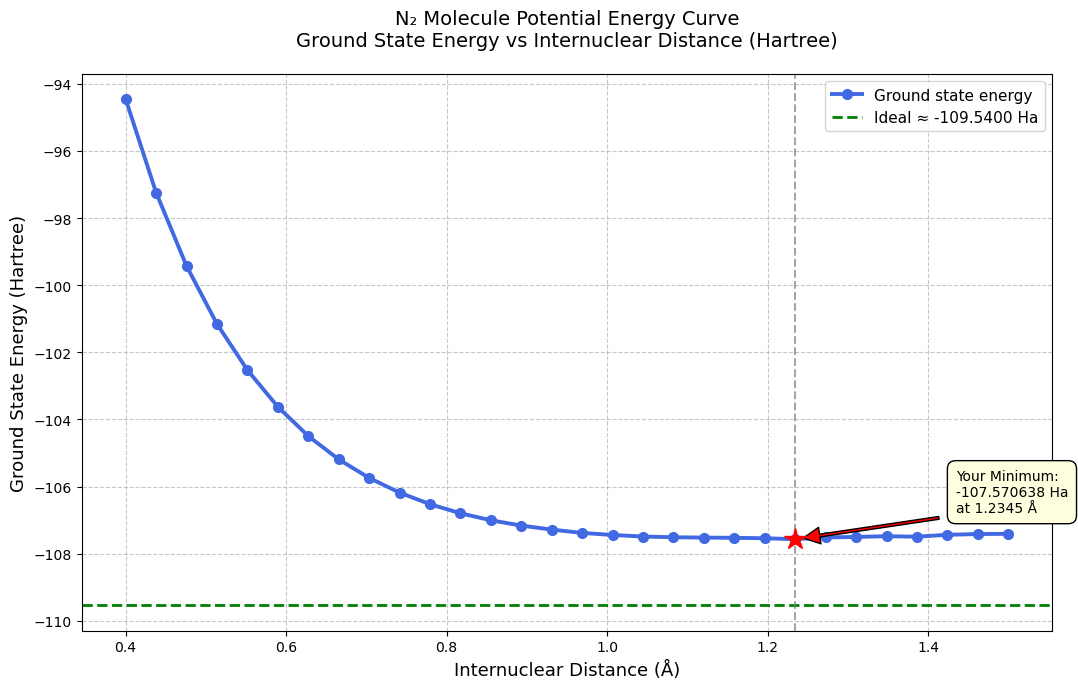

=== N₂ RESULTS (Hartree) ===
Minimum ground state energy : -107.57063833 Ha
Equilibrium bond distance    : 1.2345 Å

Reference:
Experimental bond length     : 1.0977 Å
High-accuracy energy         : -109.5400 Ha


In [4]:

# ====================== REFERENCE VALUES ======================
IDEAL_ENERGY_HA = -109.54     # High-accuracy theoretical (approx)
EXACT_DISTANCE = 1.0977       # Experimental bond length (Å)

# ====================== FIND MINIMUM ======================
min_energy_ha = min(energies_N2)
min_index = energies_N2.index(min_energy_ha)
eq_distance = distances_N2[min_index]

# ====================== PLOTTING ======================
plt.figure(figsize=(11, 7))

plt.plot(distances_N2, energies_N2, 'o-', 
         color='royalblue', markersize=7, linewidth=2.8, 
         label='Ground state energy')

plt.plot(eq_distance, min_energy_ha, 'r*', markersize=16, zorder=5)

plt.axhline(y=IDEAL_ENERGY_HA, color='green', linestyle='--', linewidth=2,
            label=f'Ideal ≈ {IDEAL_ENERGY_HA:.4f} Ha')

plt.axvline(x=eq_distance, color='gray', linestyle='--', alpha=0.7)

plt.annotate(f'Your Minimum:\n{min_energy_ha:.6f} Ha\nat {eq_distance:.4f} Å',
             xy=(eq_distance, min_energy_ha),
             xytext=(eq_distance + 0.2, min_energy_ha + 0.8),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2),
             bbox=dict(boxstyle="round,pad=0.6", facecolor="lightyellow"))

plt.xlabel("Internuclear Distance (Å)", fontsize=13)
plt.ylabel("Ground State Energy (Hartree)", fontsize=13)

plt.title("N₂ Molecule Potential Energy Curve\nGround State Energy vs Internuclear Distance (Hartree)", 
          fontsize=14, pad=20)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ====================== RESULTS ======================
print("=== N₂ RESULTS (Hartree) ===")
print(f"Minimum ground state energy : {min_energy_ha:.8f} Ha")
print(f"Equilibrium bond distance    : {eq_distance:.4f} Å")
print(f"\nReference:")
print(f"Experimental bond length     : {EXACT_DISTANCE:.4f} Å")
print(f"High-accuracy energy         : {IDEAL_ENERGY_HA:.4f} Ha")

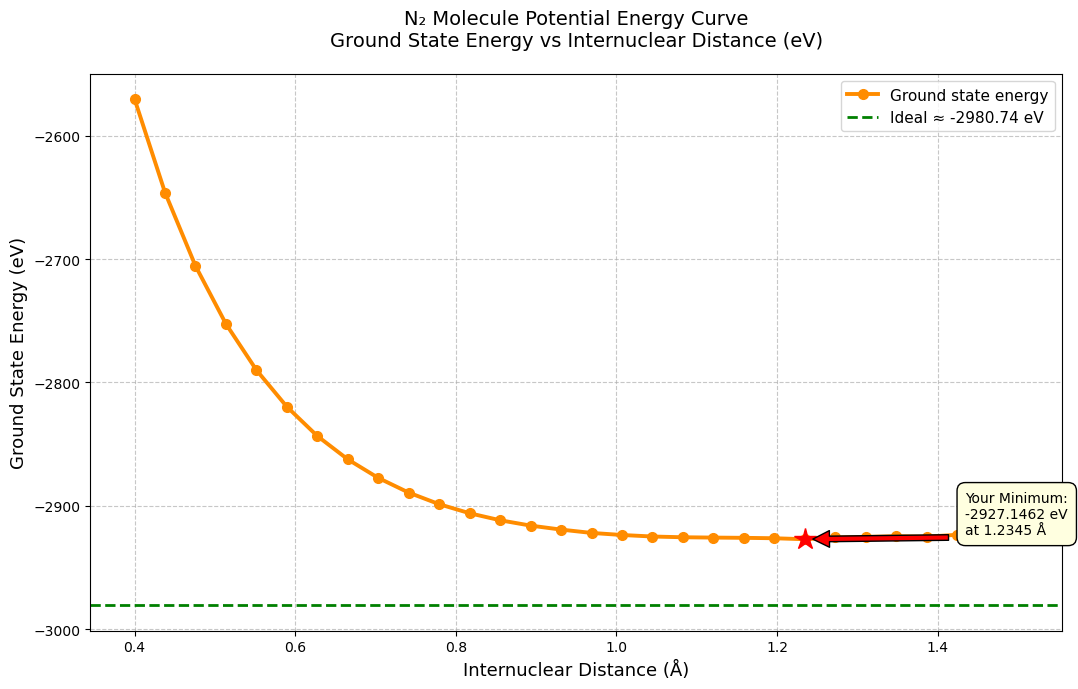

=== N₂ RESULTS (eV) ===
Minimum ground state energy : -2927.14616 eV
Equilibrium bond distance   : 1.2345 Å
Experimental bond length    : 1.0977 Å


In [5]:

HARTREE_TO_EV = 27.21138602

# Convert to eV
energies_ev = [e * HARTREE_TO_EV for e in energies_N2]

min_energy_ev = min(energies_ev)
min_index = energies_ev.index(min_energy_ev)
eq_distance = distances_N2[min_index]

IDEAL_EV = -109.54 * HARTREE_TO_EV
EXACT_DISTANCE = 1.0977

plt.figure(figsize=(11, 7))

plt.plot(distances_N2, energies_ev, 'o-', 
         color='darkorange', markersize=7, linewidth=2.8, 
         label='Ground state energy')

plt.plot(eq_distance, min_energy_ev, 'r*', markersize=16)

plt.axhline(y=IDEAL_EV, color='green', linestyle='--', linewidth=2,
            label=f'Ideal ≈ {IDEAL_EV:.2f} eV')

plt.annotate(f'Your Minimum:\n{min_energy_ev:.4f} eV\nat {eq_distance:.4f} Å',
             xy=(eq_distance, min_energy_ev),
             xytext=(eq_distance + 0.2, min_energy_ev + 4),
             arrowprops=dict(facecolor='red', shrink=0.05),
             bbox=dict(boxstyle="round,pad=0.6", facecolor="lightyellow"))

plt.xlabel("Internuclear Distance (Å)", fontsize=13)
plt.ylabel("Ground State Energy (eV)", fontsize=13)

plt.title("N₂ Molecule Potential Energy Curve\nGround State Energy vs Internuclear Distance (eV)", 
          fontsize=14, pad=20)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Results
print("=== N₂ RESULTS (eV) ===")
print(f"Minimum ground state energy : {min_energy_ev:.5f} eV")
print(f"Equilibrium bond distance   : {eq_distance:.4f} Å")
print(f"Experimental bond length    : {EXACT_DISTANCE:.4f} Å")